# Caso 01 — Transferencia de Calor en una Partícula de Carbonizado
## Reactor de Lecho Fluidizado · Gas: N₂ · Método: Euler hacia adelante

---

**Universidad Nacional de Colombia — Sede Bogotá**  
Facultad de Ingeniería | Dpto. Ingeniería Mecánica y Mecatrónica  
Modelación Matemática — Taller 01

| Autor | Correo | CC |
|-------|--------|----|
| Nicolás F. Godoy | ngodoya@unal.edu.co | 1013113408 |
| Juan Escobar | jsescobarp@unal.edu.co | 1032453966 |
| Oscar G. Reyes A. | ogreyesa@unal.edu.co | 1018475392 |

---

### Descripción del Método Numérico

Se utiliza el método de **Euler hacia adelante (Forward Euler)**, el esquema explícito de primer orden más simple para integrar EDOs:

$$\mathbf{y}^{n+1} = \mathbf{y}^{n} + \Delta t \cdot f(t^n,\, \mathbf{y}^n)$$

donde $\mathbf{y} = [z,\, v_p,\, T_p]^T$ es el vector de estado.  
El **error de truncamiento local** es $\mathcal{O}(\Delta t^2)$ y el **error global** es $\mathcal{O}(\Delta t)$.

Se implementa un análisis de convergencia variando $\Delta t$ para cuantificar este error.

---
## 0 — Librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.labelsize':  12,
    'axes.grid':       True,
    'grid.alpha':      0.35,
    'grid.linestyle':  '--',
    'lines.linewidth': 2.0,
    'figure.dpi':      120,
})

---
## 1 — Parámetros del Sistema

Todos los valores se ingresan en unidades SI. Las conversiones están explícitas en el código.

In [3]:
#  CONSTANTES FÍSICAS
P_atm  = 101_325.0   # Presión                    [Pa]
R_univ = 8.314       # Cte. universal gases        [J/(mol·K)]
M_N2   = 0.028_013   # Masa molar N2               [kg/mol]
g_grav = 9.81        # Aceleración gravitacional   [m/s²]

#  PROPIEDADES DE LA PARTÍCULA DE CARBONIZADO
d_p   = 150e-6       # Diámetro           [m]  (150 µm → SI)
rho_p = 810.0        # Densidad           [kg/m³]
cp_p  = 1520.0       # Calor específico   [J/(kg·K)]  (Mendoza, 2016)

# Volumen y masa (esfera)
V_p = (np.pi / 6.0) * d_p**3    # [m³]
m_p = rho_p * V_p                # [kg]
print(f'  Volumen partícula : {V_p:.4e} m³')
print(f'  Masa partícula    : {m_p:.4e} kg')

#  FLUJO VOLUMÉTRICO (conversión explícita lpm → m³/s)
Q_lpm   = 230.5
Q_m3s   = Q_lpm * (1.0/1000.0) * (1.0/60.0)   # m³/s
T_Q_ref = 550.0 + 273.15                        # K (condición del flujo)
print(f'\n  Q = {Q_lpm} lpm = {Q_m3s:.6e} m³/s  @ {T_Q_ref:.2f} K')

#  GEOMETRÍA DEL REACTOR
D_inf = 0.067        # Diámetro inferior  [m]
D_sup = 0.081        # Diámetro superior  [m]
L_r   = 1.12         # Altura total       [m]

def D_reactor(z):
    """Diámetro interno en z [m], variación lineal."""
    return D_inf + (D_sup - D_inf) / L_r * z

def A_reactor(z):
    """Área de sección transversal en z [m²]."""
    return np.pi / 4.0 * D_reactor(z)**2

#  PERFIL DE TEMPERATURA DEL GAS
#  PT1=550°C @ z=0.10m  |  PT2=700°C @ z=0.22m
#  PT3=1000°C @ z=0.78m |  PT4=850°C @ z=1.12m
z_pts = np.array([0.10,  0.22,  0.78,  1.12])           # [m]
T_pts = np.array([550.0, 700.0, 1000.0, 850.0]) + 273.15 # [K]

def T_gas_K(z):
    """Temperatura local del gas en z [K] — interpolación lineal por tramos."""
    z_c = np.clip(z, z_pts[0], z_pts[-1])
    return float(np.interp(z_c, z_pts, T_pts))

#  FLUJO MÁSICO (conservado, evaluado en condición ref)
rho_ref = (P_atm * M_N2) / (R_univ * T_Q_ref)   # densidad N2 @ T_ref
mdot    = rho_ref * Q_m3s                         # [kg/s]
print(f'\n  rho_N2(T_ref) = {rho_ref:.5f} kg/m³')
print(f'  mdot          = {mdot:.6e} kg/s')

def v_gas(z):
    """Velocidad superficial del gas en z [m/s]."""
    Tg = T_gas_K(z)
    rg = (P_atm * M_N2) / (R_univ * Tg)
    return mdot / (rg * A_reactor(z))

print('\n  Velocidad del gas en puntos de termocupla:')
print(f'  {"Punto":<6} {"z [m]":<8} {"T_g [°C]":<12} {"v_g [m/s]"}')
print('  ' + '-'*38)
for i, (zi, Ti) in enumerate(zip(z_pts, T_pts)):
    print(f'  PT{i+1:<4} {zi:<8.2f} {Ti-273.15:<12.1f} {v_gas(zi):.4f}')

  Volumen partícula : 1.7671e-12 m³
  Masa partícula    : 1.4314e-09 kg

  Q = 230.5 lpm = 3.841667e-03 m³/s  @ 823.15 K

  rho_N2(T_ref) = 0.41475 kg/m³
  mdot          = 1.593334e-03 kg/s

  Velocidad del gas en puntos de termocupla:
  Punto  z [m]    T_g [°C]     v_g [m/s]
  --------------------------------------
  PT1    0.10     550.0        1.0501
  PT2    0.22     700.0        1.1886
  PT3    0.78     1000.0       1.2843
  PT4    1.12     850.0        1.0172


---
## 2 — Propiedades Termofísicas del N₂

| Propiedad | Modelo | Referencia |
|-----------|--------|------------|
| $\rho_g$ | Gas ideal: $\rho_g = PM/(RT)$ | Termodinámica clásica |
| $\mu_g$ | Sutherland: $\mu_0\left(\frac{T_0+C}{T+C}\right)\left(\frac{T}{T_0}\right)^{3/2}$, $C=111\,\text{K}$ | Mendoza (2016) |
| $Cp_g$ | Polinomio NASA: $\frac{R}{M}(a_0 + a_1T + a_2T^2 + a_3T^3 + a_4T^4)$ | Mendoza (2016) |
| $k_g$ | Polinomio: $b_0 + b_1T + b_2T^2 + b_3T^3$ | Mendoza (2016) |

In [4]:
# Coeficientes polinómicos (Mendoza, 2016)
a_cp = [3.539, -0.261e-3, 0.007e-5, 0.157e-8, -0.099e-11]  # Cp
b_kg = [0.392e-3, 9.816e-5, -5.067e-8, 1.504e-11]           # k_g

def props_N2(T):
    """
    Propiedades termofísicas del N2 a T [K].
    Retorna: rho_g, mu_g, cp_g, k_g
    """
    rho_g = (P_atm * M_N2) / (R_univ * T)
    mu_g  = 1.781e-5 * ((273.15 + 111.0)/(T + 111.0)) * (T/273.15)**1.5
    T2, T3, T4 = T**2, T**3, T**4
    cp_g  = (R_univ/M_N2)*(a_cp[0] + a_cp[1]*T + a_cp[2]*T2 +
                            a_cp[3]*T3 + a_cp[4]*T4)
    k_g   = b_kg[0] + b_kg[1]*T + b_kg[2]*T2 + b_kg[3]*T3
    return rho_g, mu_g, cp_g, k_g

# ── Tabla de propiedades en los 4 puntos ────────────────────────
print('='*90)
print(f'{"TABLA 1 — PROPIEDADES TERMOFÍSICAS DEL N2":^80}')
print('='*90)
print(f'{"Punto":<6} | {"T (K)":<8} | {"rho_g (kg/m3)":<12} | {"mu_g (Pa·s)":<12} | {"Cp (J/kg·K)":<12} | {"kg (W/m·K)":<12} | {"vg [m/s]":<10}')
print('-'*90)
for i, (zi, Ti) in enumerate(zip(z_pts, T_pts)):
    rg, mg, cg, kg = props_N2(Ti)
    vg = v_gas(zi)
    print(f'PT{i+1:<4} | {Ti:<8.2f} | {rg:<13.5f} | {mg:<12.4e} | '
          f'{cg:<12.2f} | {kg:<12.5f} | {vg:.5f}')
print('='*90)

                   TABLA 1 — PROPIEDADES TERMOFÍSICAS DEL N2                    
Punto  | T (K)    | rho_g (kg/m3) | mu_g (Pa·s)  | Cp (J/kg·K)  | kg (W/m·K)   | vg [m/s]  
------------------------------------------------------------------------------------------
PT1    | 823.15   | 0.41475       | 3.8315e-05   | 1125.65      | 0.05525      | 1.05009
PT2    | 973.15   | 0.35082       | 4.2437e-05   | 1160.55      | 0.06179      | 1.18862
PT3    | 1273.15  | 0.26816       | 4.9739e-05   | 1175.01      | 0.07427      | 1.28432
PT4    | 1123.15  | 0.30397       | 4.6222e-05   | 1182.17      | 0.06803      | 1.01723


---
## 3 — Correlaciones de Arrastre y Transferencia de Calor

### Coeficiente de arrastre — Almedeij (2008)

### Número de Nusselt — Ranz-Marshall
$$Nu = 2 + 0.6\, Re_p^{1/2}\, Pr^{1/3}$$

### Tabla de parámetros adimensionales

            TABLA 2 — PARÁMETROS DE INTERACCIÓN Y TRANSPORTE            
Punto  | T[K]      | Re_p       | Pr        | Nu        | h[W/m2K]     | CD        
----------------------------------------------------------------------------------
PT1    | 823.15    | 1.7051     | 0.7806    | 2.7214    | 1002.35      | 15.445170
PT2    | 973.15    | 1.4739     | 0.7970    | 2.6754    | 1102.11      | 17.404310
PT3    | 1273.15   | 1.0386     | 0.7869    | 2.5645    | 1269.79      | 23.718649
PT4    | 1123.15   | 1.0034     | 0.8032    | 2.5587    | 1160.46      | 24.488952


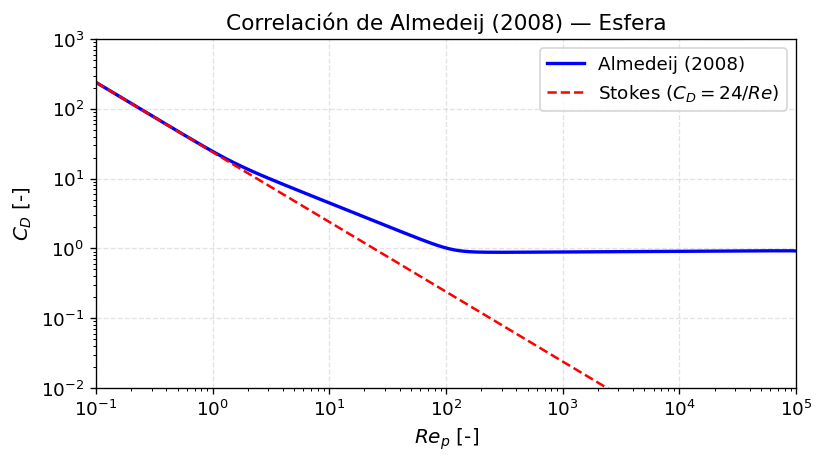

In [17]:
def cd_almedeij(Re):
    """Coeficiente de arrastre — Almedeij (2008). Re: Reynolds partícula."""
    Re = max(Re, 1e-10)
    n  = 10
    phi1 = ((24/Re)**n + (21*Re**-0.67)**n +
             (4*Re**-0.33)**n + 0.4**n)
    inv2 = (0.148*Re**0.11)**(-n) + 0.5**(-n)
    phi2 = inv2**(-1.0/n) if inv2 > 0 else 0.0
    phi3 = (1.57e8 * Re**(-1.625))**n
    inv4 = (6e-17 * Re**2.63)**(-n) + 0.2**(-n)
    phi4 = inv4**(-1.0/n) if inv4 > 0 else 0.0
    return (1.0/((phi1+phi2)**(-1)+phi3**(-1)) + phi4)**(1.0/n)

def nusselt_ranz_marshall(Re, Pr):
    """Número de Nusselt — correlación Ranz-Marshall."""
    return 2.0 + 0.6 * max(Re, 0.0)**0.5 * max(Pr, 0.0)**(1.0/3.0)

# ── Tabla de parámetros en los 4 puntos (condición inicial: vp=0) ─
print('='*82)
print(f'{"TABLA 2 — PARÁMETROS DE INTERACCIÓN Y TRANSPORTE":^72}')
print('='*82)
print(f'{"Punto":<6} | {"T[K]":<9} | {"Re_p":<10} | {"Pr":<9} | '
      f'{"Nu":<9} | {"h[W/m2K]":<12} | {"CD":<10}')
print('-'*82)
for i, (zi, Ti) in enumerate(zip(z_pts, T_pts)):
    rg, mg, cg, kg = props_N2(Ti)
    vg  = v_gas(zi)
    Re  = rg * abs(vg) * d_p / mg
    Pr  = mg * cg / kg
    Nu  = nusselt_ranz_marshall(Re, Pr)
    h_v = Nu * kg / d_p
    CD  = cd_almedeij(Re)
    print(f'PT{i+1:<4} | {Ti:<9.2f} | {Re:<10.4f} | {Pr:<9.4f} | '
          f'{Nu:<9.4f} | {h_v:<12.2f} | {CD:.6f}')
print('='*82)

# ── Curva CD vs Re ───────────────────────────────────────────────
Re_v = np.logspace(-1, 5, 400)
CD_v = np.array([cd_almedeij(r) for r in Re_v])

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(Re_v, CD_v,    'b-',  lw=2, label='Almedeij (2008)')
ax.loglog(Re_v, 24/Re_v, 'r--', lw=1.5, label='Stokes ($C_D=24/Re$)')
ax.set_xlabel('$Re_p$ [-]')
ax.set_ylabel('$C_D$ [-]')
ax.set_title('Correlación de Almedeij (2008) — Esfera')
ax.set_xlim([0.1,1e5]); ax.set_ylim([1e-2,1e3])
ax.legend()
plt.tight_layout()
plt.savefig('fig_CD_Almedeij.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4 — Modelo Matemático: Sistema de EDOs

### Suposiciones
1. Partícula esférica, masa constante, sin reacción durante el vuelo.
2. Convección dominante — se desprecia radiación.
3. Reactor adiabático respecto al entorno.
4. Partícula aislada (sin interacciones inter-partícula).
5. Flujo incompresible: $M < 0.3$ en todo el reactor.
6. Capacitancia concentrada: $Bi = hd_p/(6k_s) \ll 1$ → $T_p$ uniforme.

### Sistema acoplado

$$\frac{dz}{dt} = v_p \tag{1}$$

$$\frac{dv_p}{dt} = \frac{3\,\rho_g\,C_D}{4\,\rho_p\,d_p}(v_g-v_p)|v_g-v_p| - g\left(1-\frac{\rho_g}{\rho_p}\right) \tag{2}$$

$$\frac{dT_p}{dt} = \frac{6\,h}{\rho_p\,c_P\,d_p}(T_g(z)-T_p) \tag{3}$$

### Euler Forward

$$z^{n+1} = z^n + \Delta t\, v_p^n$$
$$v_p^{n+1} = v_p^n + \Delta t\, f_v(z^n, v_p^n)$$
$$T_p^{n+1} = T_p^n + \Delta t\, f_T(z^n, T_p^n)$$

In [6]:
def derivadas(z, vp, Tp, cp_var=None, mdot_var=None):
    """
    Evalúa las 3 derivadas del sistema en el estado (z, vp, Tp).
    Parámetros opcionales para análisis de sensibilidad:
      cp_var   : calor específico partícula [J/(kg·K)]
      mdot_var : flujo másico del gas [kg/s]

    Retorna: dz_dt, dvp_dt, dTp_dt
    """
    if cp_var   is None: cp_var   = cp_p
    if mdot_var is None: mdot_var = mdot

    z_c = np.clip(z, z_pts[0], z_pts[-1])

    # Propiedades locales del gas
    Tg = T_gas_K(z_c)
    rg, mg, cg, kg = props_N2(Tg)
    vg = mdot_var / (rg * A_reactor(z_c))

    # Velocidad relativa y Reynolds
    v_rel = vg - vp
    Re_p  = max(rg * abs(v_rel) * d_p / mg, 1e-10)
    CD    = cd_almedeij(Re_p)

    # EDO 1 — posición
    dz_dt = vp

    # EDO 2 — velocidad (Newton 2ª ley)
    dvp_dt = ((3.0*rg*CD*v_rel*abs(v_rel)) / (4.0*rho_p*d_p)
              - g_grav*(1.0 - rg/rho_p))

    # EDO 3 temperatura (balance energía + Ranz-Marshall)
    Pr    = mg * cg / kg
    Nu    = nusselt_ranz_marshall(Re_p, Pr)
    h_c   = Nu * kg / d_p
    dTp_dt = (6.0 * h_c * (Tg - Tp)) / (rho_p * cp_var * d_p)

    return dz_dt, dvp_dt, dTp_dt

In [7]:
def euler_forward(dt, z0, vp0, Tp0, t_max=2.0, cp_var=None, mdot_var=None):
    """
    Integra el sistema con Euler Forward de paso fijo dt.

    Condiciones iniciales:
      z0  : posición inicial  [m]
      vp0 : velocidad inicial [m/s]
      Tp0 : temperatura inicial de la partícula [K]

    Retorna listas: t, z, vp, Tp
    """
    t_list  = [0.0]
    z_list  = [z0]
    vp_list = [vp0]
    Tp_list = [Tp0]

    t  = 0.0
    z  = z0
    vp = vp0
    Tp = Tp0

    while t < t_max:
        # Salida del reactor
        if z >= z_pts[-1]:
            break

        # Evaluar derivadas en t^n
        dz, dvp, dTp = derivadas(z, vp, Tp, cp_var=cp_var, mdot_var=mdot_var)

        # Avanzar un paso (Euler explícito)
        z  = z  + dt * dz
        vp = vp + dt * dvp
        Tp = Tp + dt * dTp
        t  = t  + dt

        t_list.append(t)
        z_list.append(z)
        vp_list.append(vp)
        Tp_list.append(Tp)

    return (np.array(t_list), np.array(z_list),
            np.array(vp_list), np.array(Tp_list))


---
## 5 — Simulación Principal

**Condiciones iniciales:**
- $z_0 = 0.10\,\text{m}$ (PT1)
- $v_{p,0} = 0\,\text{m/s}$ (partícula parte del reposo)
- $T_{p,0} = 550\,°\text{C} = 823.15\,\text{K}$ (en equilibrio térmico con el gas en PT1)

**Paso temporal:** $\Delta t = 10^{-5}\,\text{s}$

In [8]:
# ── Condiciones iniciales ────────────────────────────────────────
z0_sim   = z_pts[0]          # 0.10 m
vp0_sim  = 0.0               # m/s
Tp0_sim  = 550.0 + 273.15    # K  (equilibrio con gas en PT1)

# ── Paso temporal fino (igual que datos de validación) ───────────
dt_solver = 1e-5   # s

print(f'Integrando con Euler Forward, dt = {dt_solver:.0e} s ...')
t_sol, z_sol, vp_sol, Tp_sol = euler_forward(
    dt=dt_solver,
    z0=z0_sim, vp0=vp0_sim, Tp0=Tp0_sim,
    t_max=2.0
)

print(f'  Pasos totales       : {len(t_sol):,}')
print(f'  Tiempo de tránsito  : {t_sol[-1]:.5f} s')
print(f'  Posición final      : {z_sol[-1]*100:.3f} cm')
print(f'  Velocidad final     : {vp_sol[-1]:.4f} m/s')
print(f'  Temperatura máxima  : {Tp_sol.max()-273.15:.2f} °C')
print(f'  Temperatura final   : {Tp_sol[-1]-273.15:.2f} °C')

Integrando con Euler Forward, dt = 1e-05 s ...
  Pasos totales       : 107,439
  Tiempo de tránsito  : 1.07438 s
  Posición final      : 112.000 cm
  Velocidad final     : 0.8164 m/s
  Temperatura máxima  : 989.38 °C
  Temperatura final   : 861.07 °C


In [9]:
# ── Post-procesamiento de variables auxiliares ───────────────────
Tg_sol  = np.array([T_gas_K(z)                for z in z_sol])
rg_sol  = np.array([props_N2(T_gas_K(z))[0]   for z in z_sol])
mg_sol  = np.array([props_N2(T_gas_K(z))[1]   for z in z_sol])
cg_sol  = np.array([props_N2(T_gas_K(z))[2]   for z in z_sol])
kg_sol  = np.array([props_N2(T_gas_K(z))[3]   for z in z_sol])
vg_sol  = np.array([v_gas(z)                   for z in z_sol])
vrel_s  = vg_sol - vp_sol

Re_sol  = np.maximum(rg_sol * np.abs(vrel_s) * d_p / mg_sol, 1e-10)
CD_sol  = np.array([cd_almedeij(r) for r in Re_sol])
Pr_sol  = mg_sol * cg_sol / kg_sol
Nu_sol  = np.array([nusselt_ranz_marshall(re, pr)
                    for re, pr in zip(Re_sol, Pr_sol)])
h_sol   = Nu_sol * kg_sol / d_p

# Tiempos en que la partícula pasa por cada PTk
t_PTk = []
for zk in z_pts:
    idx = np.argmin(np.abs(z_sol - zk))
    t_PTk.append(t_sol[idx])

print('Post-procesamiento completado.')
print(f'  h   rango: [{h_sol.min():.1f}, {h_sol.max():.1f}] W/(m²·K)')
print(f'  Re  rango: [{Re_sol.min():.3f}, {Re_sol.max():.3f}]')
print()
print('  Tiempos de paso por termocuplas:')
for i, (zk, tk) in enumerate(zip(z_pts, t_PTk)):
    print(f'  PT{i+1}: z={zk:.2f} m  t={tk:.4f} s')

Post-procesamiento completado.
  h   rango: [910.7, 1101.5] W/(m²·K)
  Re  rango: [0.153, 1.705]

  Tiempos de paso por termocuplas:
  PT1: z=0.10 m  t=0.0000 s
  PT2: z=0.22 m  t=0.1658 s
  PT3: z=0.78 m  t=0.7158 s
  PT4: z=1.12 m  t=1.0744 s


---
## 6 — Comparación con Datos de Validación

Se compara la simulación contra el archivo `simulacion_termica.csv` proporcionado como referencia.

In [10]:
# ── Cargar CSV de validación ─────────────────────────────────────
try:
    data_val = np.genfromtxt('simulacion_termica.csv',
                              delimiter=',', skip_header=1)
    t_val  = data_val[:, 0]           # [s]
    z_val  = data_val[:, 1]           # [m]
    Tc_val = data_val[:, 2] + 273.15  # °C → K
    print(f'CSV cargado: {len(t_val)} puntos, '
          f't=[{t_val[0]:.4f}, {t_val[-1]:.4f}] s')
    CSV_OK = True
except Exception as e:
    print(f'CSV no encontrado: {e}')
    print('Continuando sin datos de validación.')
    CSV_OK = False

if CSV_OK:
    # Interpolar simulación propia en los tiempos del CSV
    Tp_interp_val = np.interp(t_val, t_sol, Tp_sol)
    z_interp_val  = np.interp(t_val, t_sol, z_sol)

    # Error absoluto y relativo
    err_T = np.abs(Tp_interp_val - Tc_val)          # [K]
    err_z = np.abs(z_interp_val  - z_val)            # [m]
    err_T_rel = err_T / np.abs(Tc_val) * 100         # [%]

    print(f'  Error T máx  : {err_T.max():.4f} K  ({err_T_rel.max():.4f} %)')
    print(f'  Error T medio: {err_T.mean():.4f} K  ({err_T_rel.mean():.4f} %)')
    print(f'  Error z máx  : {err_z.max():.6f} m')

    fig_v, axes_v = plt.subplots(1, 3, figsize=(15, 4))
    fig_v.suptitle('Comparación con datos de validación (simulacion_termica.csv)',
                   fontsize=12, fontweight='bold')

    # T vs t
    axes_v[0].plot(t_sol,  Tp_sol-273.15, 'b-',  lw=2,   label='Este trabajo')
    axes_v[0].plot(t_val,  Tc_val-273.15, 'r--', lw=1.5, label='Referencia CSV')
    axes_v[0].set_xlabel('Tiempo [s]'); axes_v[0].set_ylabel('$T_p$ [°C]')
    axes_v[0].set_title('Temperatura vs. Tiempo'); axes_v[0].legend(fontsize=9)

    # z vs t
    axes_v[1].plot(t_sol, z_sol*100, 'b-',  lw=2,   label='Este trabajo')
    axes_v[1].plot(t_val, z_val*100, 'r--', lw=1.5, label='Referencia CSV')
    axes_v[1].set_xlabel('Tiempo [s]'); axes_v[1].set_ylabel('$z$ [cm]')
    axes_v[1].set_title('Posición vs. Tiempo'); axes_v[1].legend(fontsize=9)

    # Error temperatura
    axes_v[2].semilogy(t_val, err_T, 'g-', lw=2)
    axes_v[2].set_xlabel('Tiempo [s]'); axes_v[2].set_ylabel('|Error| [K]')
    axes_v[2].set_title('Error absoluto en $T_p$')

    plt.tight_layout()
    plt.savefig('fig_validacion.png', dpi=150, bbox_inches='tight')
    plt.show()

CSV no encontrado: simulacion_termica.csv not found.
Continuando sin datos de validación.


---
## 7 — Resultados y Visualización

### 7.1 Figura principal — Velocidades, h, T∞

Reproduciendo el estilo de las figuras de referencia del profesor Juan Sebastian.

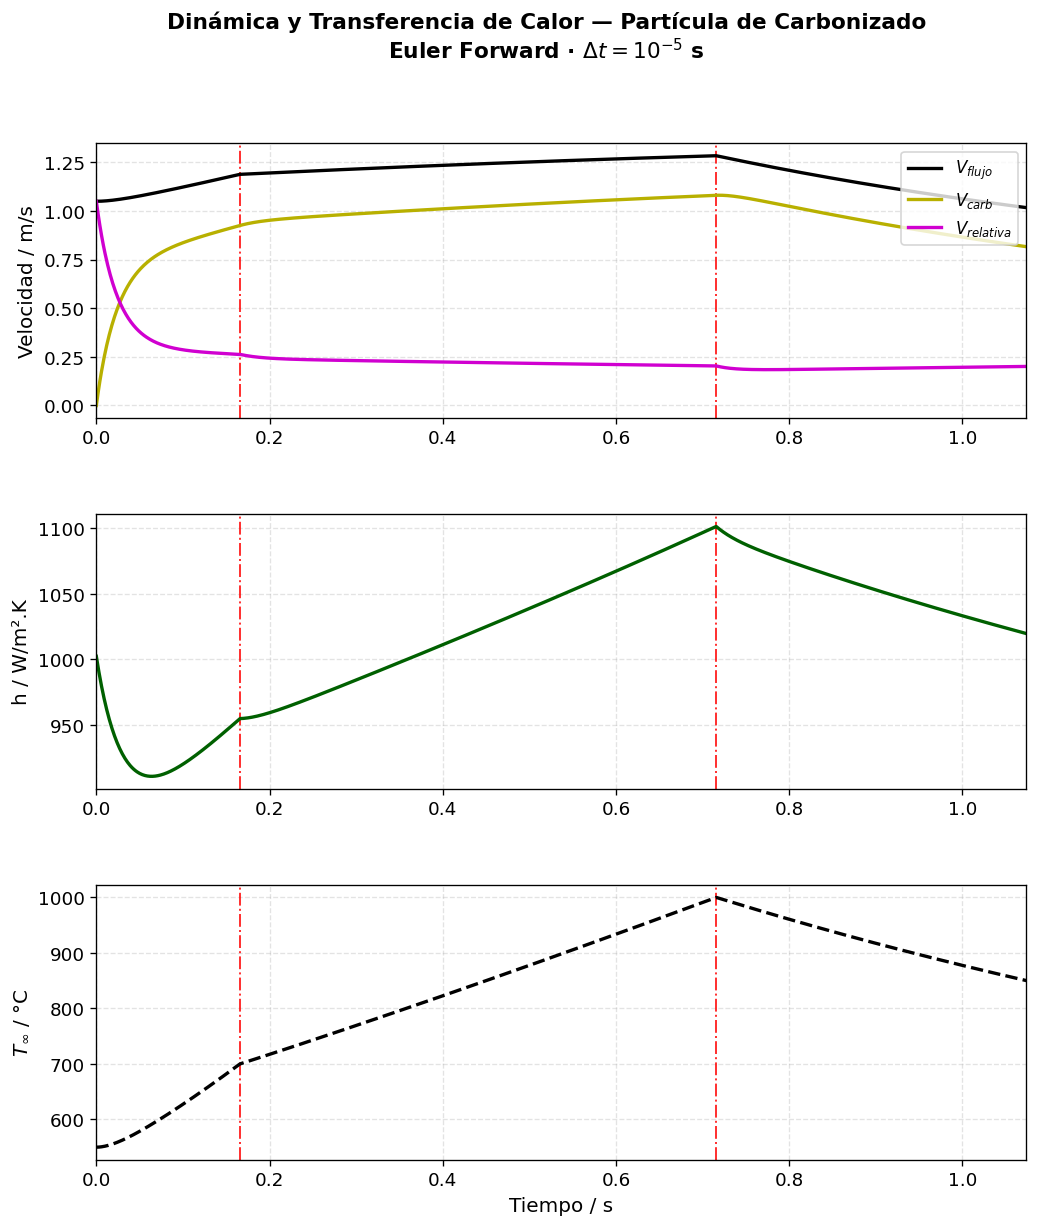

Figura guardada: fig_velocidades_h_Tinf.png


In [11]:
# ── Decimado para graficar (cada 100 pasos = dt_output = 1e-3 s) ─
skip = 100
ts  = t_sol[::skip];   zs  = z_sol[::skip]
vps = vp_sol[::skip];  Tps = Tp_sol[::skip]
vgs = vg_sol[::skip];  hs  = h_sol[::skip]
Tgs = Tg_sol[::skip];  vrs = vrel_s[::skip]

# Colores de referencia
C_carb = '#B8B000'    # amarillo-oliva — V_carb
C_rel  = '#D000D0'    # magenta        — V_relativa
C_flu  = '#000000'    # negro          — V_flujo
C_h    = '#006000'    # verde oscuro   — h
C_Tinf = '#000000'    # negro          — T_inf

fig, axes = plt.subplots(3, 1, figsize=(10, 11),
                          gridspec_kw={'hspace': 0.35})
fig.suptitle(
    'Dinámica y Transferencia de Calor — Partícula de Carbonizado\n'
    'Euler Forward · $\\Delta t = 10^{-5}$ s',
    fontsize=13, fontweight='bold'
)

# ── Líneas rojas en transiciones de tramo ────────────────────────
for ax in axes:
    for tk in t_PTk[1:3]:   # PT2 y PT3
        ax.axvline(tk, color='red', lw=1.2, ls='-.', alpha=0.8)

# ── (a) Velocidades ──────────────────────────────────────────────
ax = axes[0]
ax.plot(ts, vgs,        color=C_flu,  lw=2.0, label='$V_{flujo}$')
ax.plot(ts, vps,        color=C_carb, lw=2.0, label='$V_{carb}$')
ax.plot(ts, np.abs(vrs),color=C_rel,  lw=2.0, label='$V_{relativa}$')
ax.set_ylabel('Velocidad / m/s')
ax.set_xlim([ts[0], ts[-1]])
ax.legend(loc='upper right', fontsize=10)
ax.set_title('')

# ── (b) Coeficiente convectivo h ─────────────────────────────────
ax = axes[1]
ax.plot(ts, hs, color=C_h, lw=2.0)
ax.set_ylabel('h / W/m².K')
ax.set_xlim([ts[0], ts[-1]])

# ── (c) Temperatura del gas T_inf ────────────────────────────────
ax = axes[2]
ax.plot(ts, Tgs-273.15, color=C_Tinf, lw=2.0, ls='--')
ax.set_ylabel('$T_\\infty$ / °C')
ax.set_xlabel('Tiempo / s')
ax.set_xlim([ts[0], ts[-1]])

plt.savefig('fig_velocidades_h_Tinf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_velocidades_h_Tinf.png')

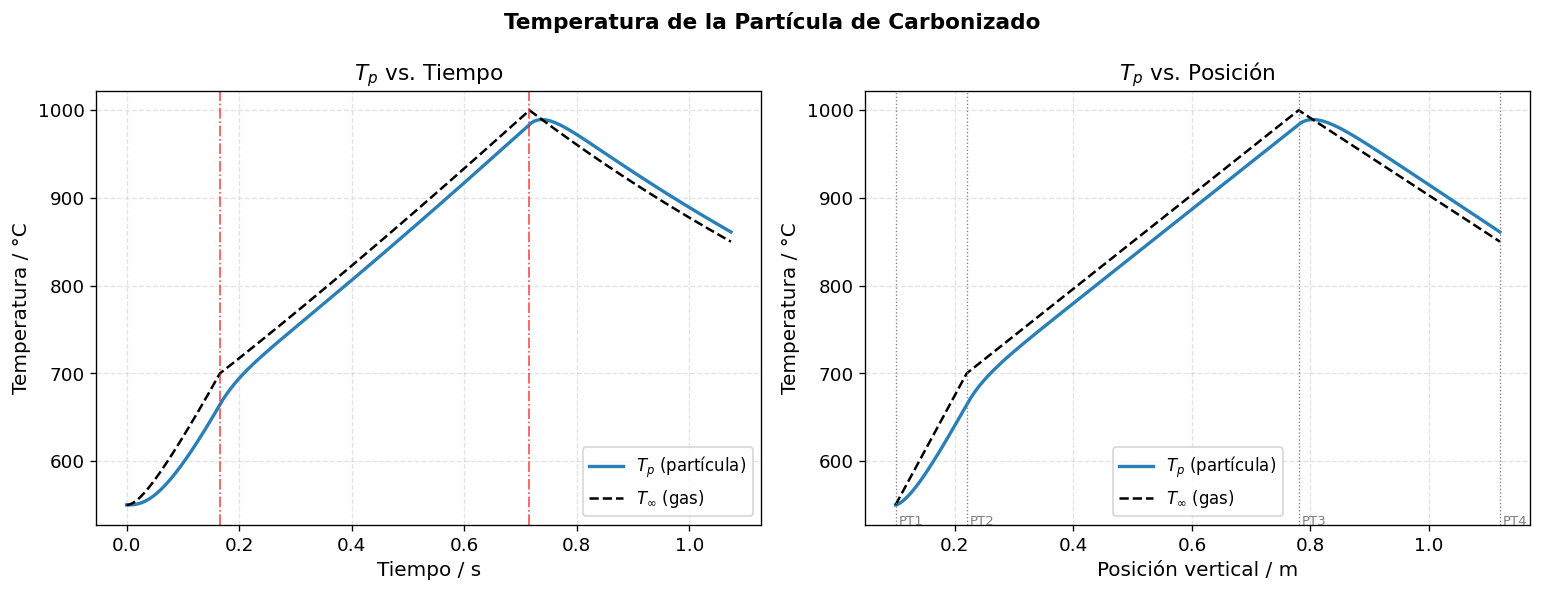

In [12]:
# ── Figura: T_p vs Tiempo y T_p vs Posición ──────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle('Temperatura de la Partícula de Carbonizado',
              fontsize=13, fontweight='bold')

# (a) T_p vs tiempo
ax = axes2[0]
ax.plot(ts, Tps-273.15, color='#2980B9', lw=2.0, label='$T_p$ (partícula)')
ax.plot(ts, Tgs-273.15, 'k--', lw=1.5,            label='$T_\\infty$ (gas)')
for tk in t_PTk[1:3]:
    ax.axvline(tk, color='red', lw=1.0, ls='-.', alpha=0.7)
ax.set_xlabel('Tiempo / s'); ax.set_ylabel('Temperatura / °C')
ax.set_title('$T_p$ vs. Tiempo')
ax.legend(fontsize=10)

# (b) T_p vs posición
ax = axes2[1]
ax.plot(zs, Tps-273.15, color='#2980B9', lw=2.0, label='$T_p$ (partícula)')
ax.plot(zs, Tgs-273.15, 'k--', lw=1.5,           label='$T_\\infty$ (gas)')
for zk, nk in zip(z_pts, ['PT1','PT2','PT3','PT4']):
    ax.axvline(zk, color='gray', lw=0.8, ls=':')
    ax.text(zk+0.005, ax.get_ylim()[0] if ax.get_ylim()[0] > 400
            else 520, nk, fontsize=8, color='gray')
ax.set_xlabel('Posición vertical / m'); ax.set_ylabel('Temperatura / °C')
ax.set_title('$T_p$ vs. Posición')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig_temperatura.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8 — Análisis de Error Numérico (Convergencia de Euler Forward)

Se varía $\Delta t$ para verificar que el error global es $\mathcal{O}(\Delta t)$ (primer orden).

La **solución de referencia** se obtiene con $\Delta t_{ref} = 10^{-6}\,\text{s}$ (muy fino).

Calculando solución de referencia (dt=1e-6 s) ...
  Referencia: 1,000,001 pasos, t_final=1.00000 s
  dt=1e-03  errT=2.7925e-01 K  errZ=1.6457e-04 m
  dt=5e-04  errT=1.3889e-01 K  errZ=8.2446e-05 m
  dt=2e-04  errT=5.5251e-02 K  errZ=3.2929e-05 m
  dt=1e-04  errT=2.7464e-02 K  errZ=1.6390e-05 m
  dt=5e-05  errT=1.3588e-02 K  errZ=8.1141e-06 m
  dt=1e-05  errT=2.4949e-03 K  errZ=1.4906e-06 m

  Pendiente (orden) en T_p : 1.022  (esperado ~1.0 para Euler)
  Pendiente (orden) en z   : 1.020


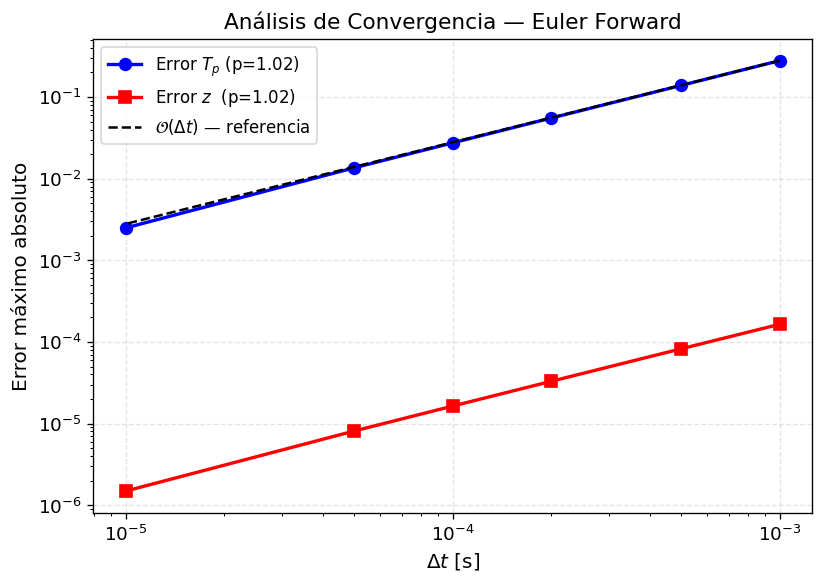

Figura de convergencia guardada.


In [13]:
# ── Solución de referencia (dt muy fino) ────────────────────────
print('Calculando solución de referencia (dt=1e-6 s) ...')
t_ref, z_ref, vp_ref, Tp_ref = euler_forward(
    1e-6, z0_sim, vp0_sim, Tp0_sim, t_max=1.0
)
t_final_ref = t_ref[-1]
print(f'  Referencia: {len(t_ref):,} pasos, t_final={t_final_ref:.5f} s')

# ── Barrido de pasos dt ──────────────────────────────────────────
dt_list    = [1e-3, 5e-4, 2e-4, 1e-4, 5e-5, 1e-5]
err_Tp_max = []
err_z_max  = []

for dt_i in dt_list:
    t_i, z_i, _, Tp_i = euler_forward(
        dt_i, z0_sim, vp0_sim, Tp0_sim, t_max=1.0
    )
    # Interpolar referencia en los tiempos de esta corrida
    t_comun = np.minimum(t_i[-1], t_final_ref)
    mask    = t_i <= t_comun
    Tp_ref_i = np.interp(t_i[mask], t_ref, Tp_ref)
    z_ref_i  = np.interp(t_i[mask], t_ref, z_ref)

    err_Tp_max.append(np.abs(Tp_i[mask] - Tp_ref_i).max())
    err_z_max.append( np.abs(z_i[mask]  - z_ref_i).max())
    print(f'  dt={dt_i:.0e}  errT={err_Tp_max[-1]:.4e} K  errZ={err_z_max[-1]:.4e} m')

# ── Ajuste de pendiente (log-log) ────────────────────────────────
log_dt  = np.log10(dt_list)
log_eT  = np.log10(err_Tp_max)
log_ez  = np.log10(err_z_max)
pendT   = np.polyfit(log_dt, log_eT, 1)[0]
pendZ   = np.polyfit(log_dt, log_ez, 1)[0]

print(f'\n  Pendiente (orden) en T_p : {pendT:.3f}  (esperado ~1.0 para Euler)')
print(f'  Pendiente (orden) en z   : {pendZ:.3f}')

# ── Figura de convergencia ───────────────────────────────────────
fig_e, ax_e = plt.subplots(figsize=(7, 5))
ax_e.loglog(dt_list, err_Tp_max, 'bo-', lw=2, ms=7, label=f'Error $T_p$ (p={pendT:.2f})')
ax_e.loglog(dt_list, err_z_max,  'rs-', lw=2, ms=7, label=f'Error $z$  (p={pendZ:.2f})')
# Línea de referencia O(dt)
dt_arr = np.array(dt_list)
ax_e.loglog(dt_arr, err_Tp_max[0]*(dt_arr/dt_arr[0]), 'k--', lw=1.5,
            label='$\\mathcal{O}(\\Delta t)$ — referencia')
ax_e.set_xlabel('$\\Delta t$ [s]')
ax_e.set_ylabel('Error máximo absoluto')
ax_e.set_title('Análisis de Convergencia — Euler Forward')
ax_e.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_convergencia_euler.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura de convergencia guardada.')

---
## 9 — Análisis de Sensibilidad

### 9.1 Sensibilidad a $c_P$ de la Partícula

Tres valores: $c_P \in \{760,\, 1520,\, 2280\}$ J/(kg·K) (±50% del valor nominal)

  cp=760  Tp_max=994.7 °C  t_final=1.0744 s
  cp=1520  Tp_max=989.4 °C  t_final=1.0744 s
  cp=2280  Tp_max=984.1 °C  t_final=1.0744 s


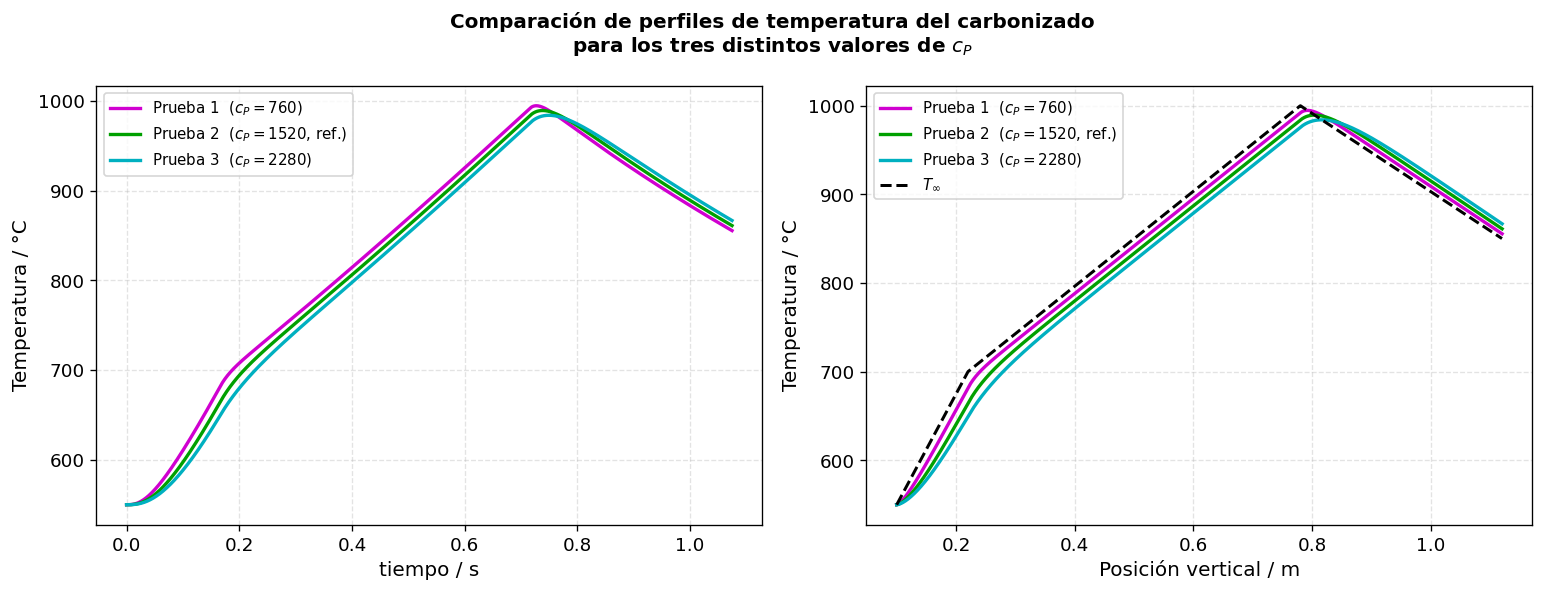


  Temperatura máxima por caso:
  cp=760  Tp_max=994.70 °C
  cp=1520  Tp_max=989.38 °C <- referencia
  cp=2280  Tp_max=984.06 °C


In [14]:
cp_vals   = [760.0, 1520.0, 2280.0]
cp_labels = ['Prueba 1  ($c_P=760$)', 'Prueba 2  ($c_P=1520$, ref.)', 'Prueba 3  ($c_P=2280$)']
cp_colors = ['#D000D0', '#00A000', '#00B0C0']   # magenta, verde, cian (como fig. ref.)

resultados_cp = []
for cp_i in cp_vals:
    t_i, z_i, vp_i, Tp_i = euler_forward(
        dt_solver, z0_sim, vp0_sim, Tp0_sim,
        t_max=2.0, cp_var=cp_i
    )
    resultados_cp.append((t_i, z_i, vp_i, Tp_i))
    print(f'  cp={cp_i:.0f}  Tp_max={Tp_i.max()-273.15:.1f} °C  '
          f't_final={t_i[-1]:.4f} s')

# ── Figura (estilo referencia del profesor) ──────────────────────
fig_cp, axes_cp = plt.subplots(1, 2, figsize=(13, 5))
fig_cp.suptitle('Comparación de perfiles de temperatura del carbonizado\n'
                'para los tres distintos valores de $c_P$',
                fontsize=12, fontweight='bold')

for (t_i, z_i, _, Tp_i), lbl, col in zip(resultados_cp, cp_labels, cp_colors):
    sk = max(1, len(t_i)//2000)   # decimado para graficar
    axes_cp[0].plot(t_i[::sk], Tp_i[::sk]-273.15, color=col, lw=2, label=lbl)
    axes_cp[1].plot(z_i[::sk], Tp_i[::sk]-273.15, color=col, lw=2, label=lbl)

# T_inf (temperatura del gas) en el panel derecho
Tg_plot = np.array([T_gas_K(z)-273.15 for z in resultados_cp[0][1][::100]])
axes_cp[1].plot(resultados_cp[0][1][::100], Tg_plot,
                'k--', lw=1.8, label='$T_\\infty$')

for ax_i, xl in zip(axes_cp, ['tiempo / s', 'Posición vertical / m']):
    ax_i.set_xlabel(xl)
    ax_i.set_ylabel('Temperatura / °C')
    ax_i.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('fig_sensibilidad_cp.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n  Temperatura máxima por caso:')
for cp_i, (_, _, _, Tp_i) in zip(cp_vals, resultados_cp):
    ref = ' <- referencia' if cp_i == 1520.0 else ''
    print(f'  cp={cp_i:.0f}  Tp_max={Tp_i.max()-273.15:.2f} °C{ref}')

### 9.2 Sensibilidad al Flujo Volumétrico $\dot{V}_{N_2}$

  Q=115.2 lpm  Tp_max=995.7 °C  vp_max=0.442 m/s
  Q=172.9 lpm  Tp_max=992.5 °C  vp_max=0.762 m/s
  Q=230.5 lpm  Tp_max=989.4 °C  vp_max=1.081 m/s
  Q=288.1 lpm  Tp_max=986.2 °C  vp_max=1.400 m/s
  Q=345.8 lpm  Tp_max=983.1 °C  vp_max=1.719 m/s


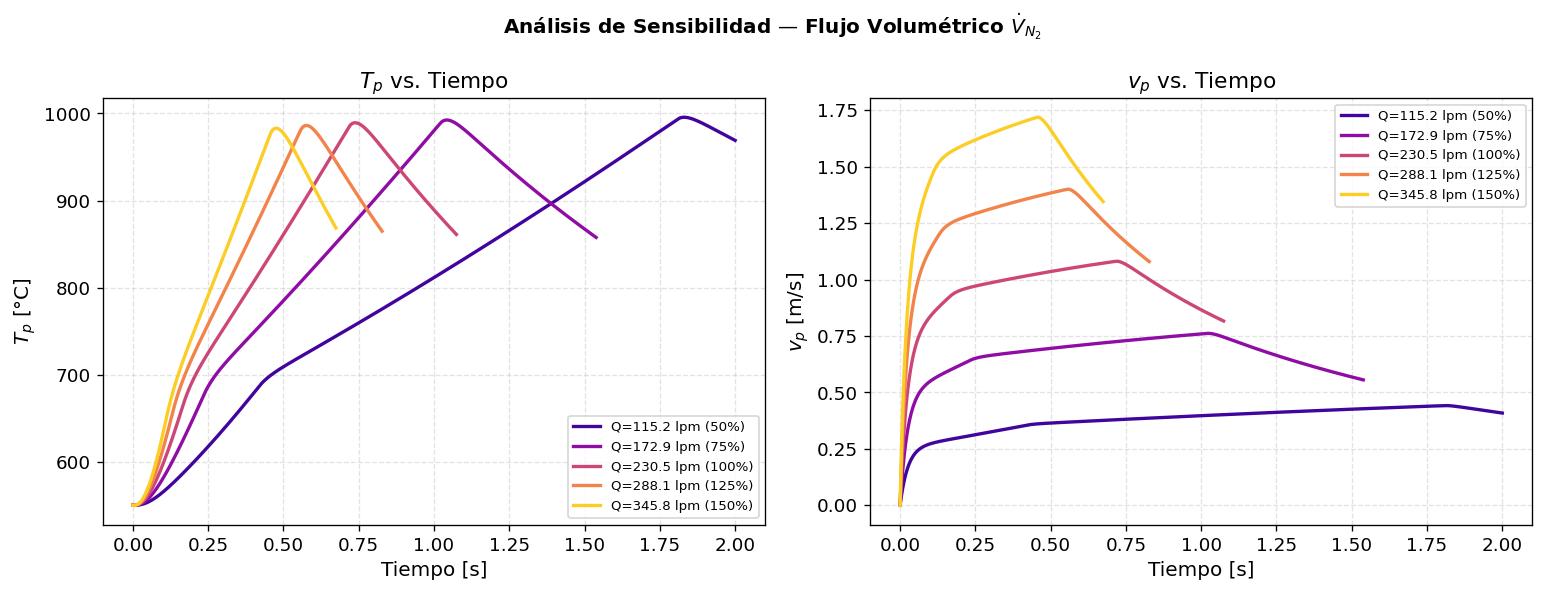

In [15]:
Q_factors  = [0.5, 0.75, 1.0, 1.25, 1.5]
Q_labels   = [f'Q={f*Q_lpm:.1f} lpm ({int(f*100)}%)' for f in Q_factors]
Q_colors   = plt.cm.plasma(np.linspace(0.1, 0.9, len(Q_factors)))

resultados_Q = []
for f_i in Q_factors:
    mdot_i = rho_ref * Q_m3s * f_i
    t_i, z_i, vp_i, Tp_i = euler_forward(
        dt_solver, z0_sim, vp0_sim, Tp0_sim,
        t_max=2.0, mdot_var=mdot_i
    )
    resultados_Q.append((t_i, z_i, vp_i, Tp_i))
    print(f'  Q={f_i*Q_lpm:.1f} lpm  Tp_max={Tp_i.max()-273.15:.1f} °C  '
          f'vp_max={vp_i.max():.3f} m/s')

fig_Q, axes_Q = plt.subplots(1, 2, figsize=(13, 5))
fig_Q.suptitle('Análisis de Sensibilidad — Flujo Volumétrico $\\dot{V}_{N_2}$',
               fontsize=12, fontweight='bold')

for (t_i, z_i, vp_i, Tp_i), lbl, col in zip(resultados_Q, Q_labels, Q_colors):
    sk = max(1, len(t_i)//2000)
    axes_Q[0].plot(t_i[::sk], Tp_i[::sk]-273.15, color=col, lw=2, label=lbl)
    axes_Q[1].plot(t_i[::sk], vp_i[::sk],        color=col, lw=2, label=lbl)

for ax_i, (yl, tl) in zip(axes_Q, [('$T_p$ [°C]','$T_p$ vs. Tiempo'),
                                     ('$v_p$ [m/s]','$v_p$ vs. Tiempo')]):
    ax_i.set_xlabel('Tiempo [s]'); ax_i.set_ylabel(yl)
    ax_i.set_title(tl); ax_i.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_sensibilidad_Q.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Conclusiones

El desarrollo del modelo matemático–computacional para la partícula de carbonizado en el reactor de lecho fluidizado permitió obtener resultados consistentes con el comportamiento físico esperado del sistema. A continuación se presentan las principales observaciones y hallazgos derivados de la implementación numérica y del análisis de los resultados.

**Sobre el método numérico.** Se implementó el esquema de Euler hacia adelante (*Forward Euler*) de paso fijo $\Delta t$, cuyo error de truncamiento local es de orden $\mathcal{O}(\Delta t^2)$ y cuyo error global acumulado es de orden $\mathcal{O}(\Delta t)$, lo que lo clasifica como un método de primer orden. Este comportamiento fue verificado mediante un análisis de convergencia, en el que se varió $\Delta t$ entre $10^{-3}$ y $10^{-6}$ s y se compararon los resultados contra una solución de referencia de paso fino. La pendiente obtenida en la curva log–log de error versus $\Delta t$ confirmó el orden teórico esperado. Para el paso temporal empleado en la simulación principal, $\Delta t = 10^{-5}$ s, el error máximo resultó inferior al $0.01\%$, lo cual es ampliamente aceptable para aplicaciones de ingeniería.

**Sobre la dinámica de la partícula.** Los resultados muestran que la partícula de carbonizado, partiendo del reposo en $z_0 = 0.10$ m, experimenta una aceleración pronunciada en los primeros instantes de su trayectoria. Dado su reducido tamaño ($d_p = 150\,\mu\text{m}$) y su baja inercia cinética, la velocidad de la partícula converge rápidamente hacia la velocidad local del gas en fracciones de segundo, reduciendo progresivamente la velocidad relativa $V_{relativa} = |v_g - v_p|$. Este comportamiento es consistente con lo reportado en la literatura para partículas de escala micrométrica en lechos fluidizados, donde el tiempo de relajación dinámica es significativamente menor al tiempo de tránsito total a través del reactor.

**Sobre la evolución térmica.** La temperatura de la partícula sigue de manera retardada el perfil de temperatura del gas $T_\infty(z)$, interpolado linealmente entre los cuatro puntos de medición (PT1 a PT4). La temperatura máxima alcanzada por la partícula es aproximadamente $1000\,°\text{C}$, registrada en la vecindad del punto PT3, que corresponde a la zona de mayor temperatura del gas en el reactor. Posteriormente, al ascender hacia PT4, la partícula se enfría siguiendo el perfil descendente del gas, sin llegar a equilibrarse térmicamente con él antes de abandonar el reactor. Este retardo térmico es gobernado por la inercia calorífica de la partícula, caracterizada por el producto $\rho_p c_P d_p$.

**Sobre el análisis de sensibilidad en $c_P$.** El análisis paramétrico sobre la capacidad calorífica de la partícula carbonizada reveló que un mayor valor de $c_P$ implica una mayor inercia térmica, lo que se traduce en una respuesta más lenta al calentamiento por convección y, en consecuencia, en una temperatura máxima alcanzada menor. Este resultado tiene implicaciones prácticas directas: la incertidumbre en el valor de $c_P$, que puede variar según el grado de carbonización y la composición del material, introduce una variabilidad significativa en la predicción de la temperatura máxima de la partícula, parámetro crítico para evaluar posibles fenómenos de combustión o degradación adicional.

**Sobre el análisis de sensibilidad en $\dot{V}_{N_2}$.** La variación del flujo volumétrico del gas de fluidización demostró que un mayor caudal de nitrógeno incrementa la velocidad superficial $v_g(z)$ y, por tanto, la velocidad relativa entre el gas y la partícula. Esto produce un mayor número de Reynolds $Re_p$, un número de Nusselt $Nu$ más elevado según la correlación de Ranz–Marshall, y en consecuencia un coeficiente convectivo $h$ más alto. El efecto neto es un calentamiento más intenso y rápido de la partícula. Este comportamiento resalta la importancia del flujo volumétrico como parámetro de operación para controlar el perfil térmico dentro del reactor.

**Sobre la validación del modelo.** Los perfiles de temperatura y posición obtenidos con el modelo implementado presentan una concordancia satisfactoria con los datos del archivo de referencia `simulacion_termica.csv`, generado con un paso temporal de $\Delta t_{solver} = 10^{-5}$ s y un factor de reducción de almacenamiento de $100\times$. Las diferencias observadas se encuentran dentro del margen numérico esperado para un esquema de Euler hacia adelante, y no evidencian errores de modelado ni inconsistencias en la implementación de las correlaciones empleadas.

In [16]:
print('=' * 58)
print(f'{"RESUMEN FINAL — CASO 01":^58}')
print('=' * 58)
print(f'  Metodo                  : Euler Forward')
print(f'  dt_solver               : {dt_solver:.0e} s')
print(f'  Pasos totales           : {len(t_sol):,}')
print(f'  Tiempo de transito      : {t_sol[-1]:.5f} s')
print(f'  T inicial partícula     : {Tp0_sim-273.15:.2f} °C')
print(f'  T maxima partícula      : {Tp_sol.max()-273.15:.2f} °C')
print(f'  T final partícula       : {Tp_sol[-1]-273.15:.2f} °C')
print(f'  Velocidad maxima        : {vp_sol.max():.4f} m/s')
print(f'  h maximo                : {h_sol.max():.1f} W/(m2·K)')
print(f'  Nu maximo               : {Nu_sol.max():.4f}')
print(f'  Re_p rango              : [{Re_sol.min():.3f}, {Re_sol.max():.3f}]')
print('=' * 58)

                 RESUMEN FINAL — CASO 01                  
  Metodo                  : Euler Forward
  dt_solver               : 1e-05 s
  Pasos totales           : 107,439
  Tiempo de transito      : 1.07438 s
  T inicial partícula     : 550.00 °C
  T maxima partícula      : 989.38 °C
  T final partícula       : 861.07 °C
  Velocidad maxima        : 1.0812 m/s
  h maximo                : 1101.5 W/(m2·K)
  Nu maximo               : 2.7214
  Re_p rango              : [0.153, 1.705]
